In [3]:
import pandas as pd
import gzip

import gzip

with gzip.open("../data/GPL570.annot.gz", "rt", encoding="utf-8", errors="ignore") as f:
    for i in range(30):
        print(f.readline())

^Annotation

!Annotation_date = Aug 09 2016

!Annotation_platform = GPL570

!Annotation_platform_title = [HG-U133_Plus_2] Affymetrix Human Genome U133 Plus 2.0 Array

!Annotation_platform_organism = Homo sapiens

#ID = ID from Platform data table

#Gene title = Entrez Gene name

#Gene symbol = Entrez Gene symbol

#Gene ID = Entrez Gene identifier

#UniGene title = Entrez UniGene name

#UniGene symbol = Entrez UniGene symbol

#UniGene ID = Entrez UniGene identifier

#Nucleotide Title = Entrez Nucleotide title

#GI = GenBank identifier

#GenBank Accession = GenBank accession

#Platform_CLONEID = CLONE_ID from Platform data table

#Platform_ORF = ORF from Platform data table

#Platform_SPOTID = SPOT_ID from Platform data table

#Chromosome location = Entrez gene chromosome and location

#Chromosome annotation = Entrez gene chromosome annotation

#GO:Function = Gene Ontology Function term

#GO:Process = Gene Ontology Process term

#GO:Component = Gene Ontology Component term

#GO:Function 

In [4]:
import gzip

with gzip.open("../data/GPL570.annot.gz", "rt", encoding="utf-8", errors="ignore") as f:
    lines = f.readlines()

for i, line in enumerate(lines):
    if "ID" in line and "Gene Symbol" in line:
        print("Found header at line:", i)
        print(line[:500])
        break

In [7]:
for i in range(100):
    print(i, lines[i][:200])

0 ^Annotation

1 !Annotation_date = Aug 09 2016

2 !Annotation_platform = GPL570

3 !Annotation_platform_title = [HG-U133_Plus_2] Affymetrix Human Genome U133 Plus 2.0 Array

4 !Annotation_platform_organism = Homo sapiens

5 #ID = ID from Platform data table

6 #Gene title = Entrez Gene name

7 #Gene symbol = Entrez Gene symbol

8 #Gene ID = Entrez Gene identifier

9 #UniGene title = Entrez UniGene name

10 #UniGene symbol = Entrez UniGene symbol

11 #UniGene ID = Entrez UniGene identifier

12 #Nucleotide Title = Entrez Nucleotide title

13 #GI = GenBank identifier

14 #GenBank Accession = GenBank accession

15 #Platform_CLONEID = CLONE_ID from Platform data table

16 #Platform_ORF = ORF from Platform data table

17 #Platform_SPOTID = SPOT_ID from Platform data table

18 #Chromosome location = Entrez gene chromosome and location

19 #Chromosome annotation = Entrez gene chromosome annotation

20 #GO:Function = Gene Ontology Function term

21 #GO:Process = Gene Ontology Process term

22 

In [8]:
for i in range(80, 100):
    print(i, lines[i][:300])

80 1552315_at	GTPase, IMAP family member 1	GIMAP1	170575				Homo sapiens GTPase, IMAP family member 1 (GIMAP1), mRNA	313760609	NM_130759				7q36.1	Chromosome 7, NC_000007.14 (150716557..150724280)	GTP binding		Golgi membrane///endoplasmic reticulum membrane///integral component of membrane	GO:0005525		
81 1552316_a_at	GTPase, IMAP family member 1	GIMAP1	170575				Homo sapiens GTPase, IMAP family member 1 (GIMAP1), mRNA	313760609	NM_130759				7q36.1	Chromosome 7, NC_000007.14 (150716557..150724280)	GTP binding		Golgi membrane///endoplasmic reticulum membrane///integral component of membrane	GO:0005525
82 1552318_at	GTPase, IMAP family member 1	GIMAP1	170575										7q36.1	Chromosome 7, NC_000007.14 (150716557..150724280)	GTP binding		Golgi membrane///endoplasmic reticulum membrane///integral component of membrane	GO:0005525		GO:0000139///GO:0005789///GO:0016021

83 1552319_a_at	kallikrein related peptidase 8	KLK8	11202				Homo sapiens kallikrein related peptidase 8 (KLK8), transcript v

In [9]:
for i, line in enumerate(lines):
    if line.startswith("ID\t"):
        print("Header found at:", i)
        print(line)
        break

Header found at: 27
ID	Gene title	Gene symbol	Gene ID	UniGene title	UniGene symbol	UniGene ID	Nucleotide Title	GI	GenBank Accession	Platform_CLONEID	Platform_ORF	Platform_SPOTID	Chromosome location	Chromosome annotation	GO:Function	GO:Process	GO:Component	GO:Function ID	GO:Process ID	GO:Component ID



In [10]:
annot = pd.read_csv(
    "../data/GPL570.annot.gz",
    sep="\t",
    skiprows=27,   # replace with actual header line
    compression="gzip",
    low_memory=False
)

print(annot.shape)
print(annot.columns)
annot.head()

(54676, 21)
Index(['ID', 'Gene title', 'Gene symbol', 'Gene ID', 'UniGene title',
       'UniGene symbol', 'UniGene ID', 'Nucleotide Title', 'GI',
       'GenBank Accession', 'Platform_CLONEID', 'Platform_ORF',
       'Platform_SPOTID', 'Chromosome location', 'Chromosome annotation',
       'GO:Function', 'GO:Process', 'GO:Component', 'GO:Function ID',
       'GO:Process ID', 'GO:Component ID'],
      dtype='str')


,ID,Gene title,Gene symbol,Gene ID,UniGene title,UniGene symbol,UniGene ID,Nucleotide Title,GI,GenBank Accession,...,Platform_ORF,Platform_SPOTID,Chromosome location,Chromosome annotation,GO:Function,GO:Process,GO:Component,GO:Function ID,GO:Process ID,GO:Component ID
0,1007_s_at,microRNA 4640///discoidin domain receptor tyro...,MIR4640///DDR1,100616237///780,NaN,NaN,NaN,"Human receptor tyrosine kinase DDR gene, compl...",1753221.0,U48705,...,NaN,NaN,6p21.3,"Chromosome 6, NC_000006.12 (30890883..30890972...",ATP binding///collagen binding///collagen bind...,branching involved in mammary gland duct morph...,basolateral plasma membrane///extracellular ex...,GO:0005524///GO:0005518///GO:0005518///GO:0046...,GO:0060444///GO:0007155///GO:0038063///GO:0038...,GO:0016323///GO:0070062///GO:0005615///GO:0005...
1,1053_at,replication factor C subunit 2,RFC2,5982,NaN,NaN,NaN,"Human replication factor C, 40-kDa subunit (A1...",1590810.0,M87338,...,NaN,NaN,7q11.23,"Chromosome 7, NC_000007.14 (74231502..74254458...",ATP binding///contributes_to DNA clamp loader ...,"DNA damage response, detection of DNA damage//...",Ctf18 RFC-like complex///DNA replication facto...,GO:0005524///contributes_to GO:0003689///GO:00...,GO:0042769///GO:0006260///GO:0070987///GO:0042...,GO:0031390///GO:0005663///GO:0005654
2,117_at,heat shock protein family A (Hsp70) member 6,HSPA6,3310,NaN,NaN,NaN,Human heat-shock protein HSP70B' gene,35221.0,X51757,...,NaN,NaN,1q23,"Chromosome 1, NC_000001.11 (161524540..161526897)","ATP binding///ATPase activity, coupled///enzym...",NOT cellular heat acclimation///cellular respo...,colocalizes_with COP9 signalosome///blood micr...,GO:0005524///GO:0042623///GO:0019899///GO:0031...,NOT GO:0070370///GO:0034605///GO:0034605///GO:...,colocalizes_with GO:0008180///GO:0072562///GO:...
3,121_at,paired box 8,PAX8,7849,NaN,NaN,NaN,H.sapiens Pax8 mRNA,38425.0,X69699,...,NaN,NaN,2q13,"Chromosome 2, NC_000002.12 (113215997..1132789...",DNA binding///DNA binding///RNA polymerase II ...,anatomical structure morphogenesis///branching...,nucleoplasm///nucleoplasm///nucleus,GO:0003677///GO:0003677///GO:0000978///GO:0000...,GO:0009653///GO:0001658///GO:0071371///GO:0007...,GO:0005654///GO:0005654///GO:0005634
4,1255_g_at,guanylate cyclase activator 1A,GUCA1A,2978,NaN,NaN,NaN,Homo sapiens guanylate cyclase activating prot...,623404.0,L36861,...,NaN,NaN,6p21.1,"Chromosome 6, NC_000006.12 (42155377..42180083)",calcium ion binding///calcium sensitive guanyl...,cellular response to calcium ion///phototransd...,photoreceptor disc membrane///photoreceptor in...,GO:0005509///GO:0008048///GO:0030249,GO:0071277///GO:0007602///GO:0031284///GO:0022...,GO:0097381///GO:0001917///GO:0005886


In [11]:
print(annot.shape)
print(annot.columns)
annot.head()

(54676, 21)
Index(['ID', 'Gene title', 'Gene symbol', 'Gene ID', 'UniGene title',
       'UniGene symbol', 'UniGene ID', 'Nucleotide Title', 'GI',
       'GenBank Accession', 'Platform_CLONEID', 'Platform_ORF',
       'Platform_SPOTID', 'Chromosome location', 'Chromosome annotation',
       'GO:Function', 'GO:Process', 'GO:Component', 'GO:Function ID',
       'GO:Process ID', 'GO:Component ID'],
      dtype='str')


,ID,Gene title,Gene symbol,Gene ID,UniGene title,UniGene symbol,UniGene ID,Nucleotide Title,GI,GenBank Accession,...,Platform_ORF,Platform_SPOTID,Chromosome location,Chromosome annotation,GO:Function,GO:Process,GO:Component,GO:Function ID,GO:Process ID,GO:Component ID
0,1007_s_at,microRNA 4640///discoidin domain receptor tyro...,MIR4640///DDR1,100616237///780,NaN,NaN,NaN,"Human receptor tyrosine kinase DDR gene, compl...",1753221.0,U48705,...,NaN,NaN,6p21.3,"Chromosome 6, NC_000006.12 (30890883..30890972...",ATP binding///collagen binding///collagen bind...,branching involved in mammary gland duct morph...,basolateral plasma membrane///extracellular ex...,GO:0005524///GO:0005518///GO:0005518///GO:0046...,GO:0060444///GO:0007155///GO:0038063///GO:0038...,GO:0016323///GO:0070062///GO:0005615///GO:0005...
1,1053_at,replication factor C subunit 2,RFC2,5982,NaN,NaN,NaN,"Human replication factor C, 40-kDa subunit (A1...",1590810.0,M87338,...,NaN,NaN,7q11.23,"Chromosome 7, NC_000007.14 (74231502..74254458...",ATP binding///contributes_to DNA clamp loader ...,"DNA damage response, detection of DNA damage//...",Ctf18 RFC-like complex///DNA replication facto...,GO:0005524///contributes_to GO:0003689///GO:00...,GO:0042769///GO:0006260///GO:0070987///GO:0042...,GO:0031390///GO:0005663///GO:0005654
2,117_at,heat shock protein family A (Hsp70) member 6,HSPA6,3310,NaN,NaN,NaN,Human heat-shock protein HSP70B' gene,35221.0,X51757,...,NaN,NaN,1q23,"Chromosome 1, NC_000001.11 (161524540..161526897)","ATP binding///ATPase activity, coupled///enzym...",NOT cellular heat acclimation///cellular respo...,colocalizes_with COP9 signalosome///blood micr...,GO:0005524///GO:0042623///GO:0019899///GO:0031...,NOT GO:0070370///GO:0034605///GO:0034605///GO:...,colocalizes_with GO:0008180///GO:0072562///GO:...
3,121_at,paired box 8,PAX8,7849,NaN,NaN,NaN,H.sapiens Pax8 mRNA,38425.0,X69699,...,NaN,NaN,2q13,"Chromosome 2, NC_000002.12 (113215997..1132789...",DNA binding///DNA binding///RNA polymerase II ...,anatomical structure morphogenesis///branching...,nucleoplasm///nucleoplasm///nucleus,GO:0003677///GO:0003677///GO:0000978///GO:0000...,GO:0009653///GO:0001658///GO:0071371///GO:0007...,GO:0005654///GO:0005654///GO:0005634
4,1255_g_at,guanylate cyclase activator 1A,GUCA1A,2978,NaN,NaN,NaN,Homo sapiens guanylate cyclase activating prot...,623404.0,L36861,...,NaN,NaN,6p21.1,"Chromosome 6, NC_000006.12 (42155377..42180083)",calcium ion binding///calcium sensitive guanyl...,cellular response to calcium ion///phototransd...,photoreceptor disc membrane///photoreceptor in...,GO:0005509///GO:0008048///GO:0030249,GO:0071277///GO:0007602///GO:0031284///GO:0022...,GO:0097381///GO:0001917///GO:0005886


In [12]:
annot_small = annot[
    ["ID", "Gene symbol", "Gene title"]
]

annot_small.head()

,ID,Gene symbol,Gene title
0,1007_s_at,MIR4640///DDR1,microRNA 4640///discoidin domain receptor tyro...
1,1053_at,RFC2,replication factor C subunit 2
2,117_at,HSPA6,heat shock protein family A (Hsp70) member 6
3,121_at,PAX8,paired box 8
4,1255_g_at,GUCA1A,guanylate cyclase activator 1A


In [15]:
import pandas as pd

sig_genes = pd.read_csv("../results/significant_genes.csv")

print(sig_genes.shape)
sig_genes.head()

(17922, 4)


,Gene,logFC,p_value,adj_p
0,205941_s_at,3.592377,2.381322e-37,1.299702e-32
1,223540_at,1.864932,3.469596e-30,9.468353e-26
2,59697_at,1.678639,1.012895e-26,1.842760e-22
3,1557289_s_at,2.127159,6.714834e-26,8.740946e-22
4,227641_at,3.054369,8.007609e-26,8.740946e-22


In [16]:
merged = sig_genes.merge(
    annot_small,
    left_on="Gene",
    right_on="ID",
    how="left"
)

In [17]:
print(merged.shape)
merged.head()

(17922, 7)


,Gene,logFC,p_value,adj_p,ID,Gene symbol,Gene title
0,205941_s_at,3.592377,2.381322e-37,1.299702e-32,205941_s_at,COL10A1,collagen type X alpha 1 chain
1,223540_at,1.864932,3.469596e-30,9.468353e-26,223540_at,NECTIN4,nectin cell adhesion molecule 4
2,59697_at,1.678639,1.012895e-26,1.842760e-22,59697_at,RAB15,"RAB15, member RAS oncogene family"
3,1557289_s_at,2.127159,6.714834e-26,8.740946e-22,1557289_s_at,GTF2IRD2,GTF2I repeat domain containing 2
4,227641_at,3.054369,8.007609e-26,8.740946e-22,227641_at,FBXL16,F-box and leucine rich repeat protein 16


In [18]:
merged = merged.sort_values("adj_p")

merged[
    [
        "Gene",
        "Gene symbol",
        "Gene title",
        "logFC",
        "adj_p"
    ]
].head(20)

,Gene,Gene symbol,Gene title,logFC,adj_p
0,205941_s_at,COL10A1,collagen type X alpha 1 chain,3.592377,1.299702e-32
1,223540_at,NECTIN4,nectin cell adhesion molecule 4,1.864932,9.468353e-26
2,59697_at,RAB15,"RAB15, member RAS oncogene family",1.678639,1.842760e-22
3,1557289_s_at,GTF2IRD2,GTF2I repeat domain containing 2,2.127159,8.740946e-22
4,227641_at,FBXL16,F-box and leucine rich repeat protein 16,3.054369,8.740946e-22
5,217428_s_at,COL10A1,collagen type X alpha 1 chain,3.562617,1.528631e-21
6,236462_at,NaN,NaN,1.567491,1.528631e-21
7,203878_s_at,MMP11,matrix metallopeptidase 11,3.404778,3.272861e-21
8,235538_at,NaN,NaN,2.539549,4.012687e-21
9,236659_x_at,NaN,NaN,1.379771,1.536862e-20


In [19]:
merged.to_csv(
    "../results/significant_genes_annotated.csv",
    index=False
)

In [20]:
top20 = merged.sort_values(
    "adj_p"
).head(20)

top20[
    [
        "Gene symbol",
        "Gene title",
        "logFC",
        "adj_p"
    ]
]

,Gene symbol,Gene title,logFC,adj_p
0,COL10A1,collagen type X alpha 1 chain,3.592377,1.299702e-32
1,NECTIN4,nectin cell adhesion molecule 4,1.864932,9.468353e-26
2,RAB15,"RAB15, member RAS oncogene family",1.678639,1.842760e-22
3,GTF2IRD2,GTF2I repeat domain containing 2,2.127159,8.740946e-22
4,FBXL16,F-box and leucine rich repeat protein 16,3.054369,8.740946e-22
5,COL10A1,collagen type X alpha 1 chain,3.562617,1.528631e-21
6,NaN,NaN,1.567491,1.528631e-21
7,MMP11,matrix metallopeptidase 11,3.404778,3.272861e-21
8,NaN,NaN,2.539549,4.012687e-21
9,NaN,NaN,1.379771,1.536862e-20


In [22]:
top20[
    [
        "Gene symbol",
        "Gene title",
        "logFC",
        "adj_p"
    ]
]

,Gene symbol,Gene title,logFC,adj_p
0,COL10A1,collagen type X alpha 1 chain,3.592377,1.299702e-32
1,NECTIN4,nectin cell adhesion molecule 4,1.864932,9.468353e-26
2,RAB15,"RAB15, member RAS oncogene family",1.678639,1.842760e-22
3,GTF2IRD2,GTF2I repeat domain containing 2,2.127159,8.740946e-22
4,FBXL16,F-box and leucine rich repeat protein 16,3.054369,8.740946e-22
5,COL10A1,collagen type X alpha 1 chain,3.562617,1.528631e-21
6,NaN,NaN,1.567491,1.528631e-21
7,MMP11,matrix metallopeptidase 11,3.404778,3.272861e-21
8,NaN,NaN,2.539549,4.012687e-21
9,NaN,NaN,1.379771,1.536862e-20


In [23]:
merged_clean = merged.dropna(
    subset=["Gene symbol"]
)

print(merged_clean.shape)

(15586, 7)


In [24]:
top20 = merged_clean.sort_values(
    "adj_p"
).head(20)

top20.to_csv(
    "../results/top20_genes.csv",
    index=False
)

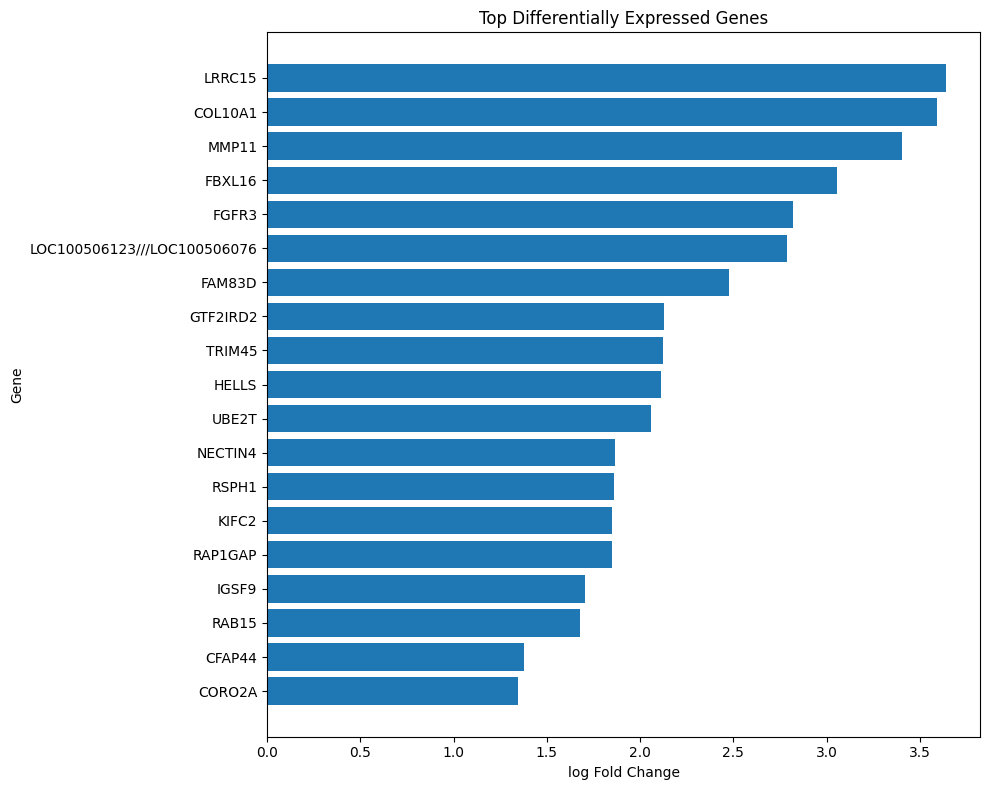

In [26]:
import matplotlib.pyplot as plt

top20_plot = top20.sort_values("logFC")

plt.figure(figsize=(10,8))

plt.barh(
    top20_plot["Gene symbol"],
    top20_plot["logFC"]
)

plt.xlabel("log Fold Change")
plt.ylabel("Gene")
plt.title("Top Differentially Expressed Genes")

plt.tight_layout()
plt.savefig(
    "../figures/top20_genes_barplot.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


In [27]:
top20[["Gene symbol","logFC","adj_p"]]

,Gene symbol,logFC,adj_p
0,COL10A1,3.592377,1.299702e-32
1,NECTIN4,1.864932,9.468353e-26
2,RAB15,1.678639,1.842760e-22
3,GTF2IRD2,2.127159,8.740946e-22
4,FBXL16,3.054369,8.740946e-22
5,COL10A1,3.562617,1.528631e-21
7,MMP11,3.404778,3.272861e-21
10,HELLS,2.110311,2.084906e-20
11,FGFR3,2.818963,2.084906e-20
12,RSPH1,1.862135,2.891448e-20
